In [58]:

# INSTALACIJA
# !pip install pandas
# !pip install openpyxl
# !pip install matplotlib
# !pip install statsmodels


In [1]:
import pandas as pd 

# Nalozi podatke iz lokalne datoteke
# fn = 'SUS_2026.xlsx'
fn = 'SUS_2025.xlsx'

column_names = ['T', 'S', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

df = pd.read_excel(fn, names=column_names)
df


,T,S,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,2025-04-16 11:44:46.692,Google,4,2,5,1,4,3,3,1,5,1
1,2025-04-16 11:46:51.837,Google,4,1,5,1,4,3,4,2,4,2
2,2025-04-16 11:47:04.977,Google,2,1,4,1,3,3,4,2,5,1
3,2025-04-16 11:47:06.790,ChatGPT,5,1,2,2,3,1,5,1,5,1
4,2025-04-16 11:48:05.884,ChatGPT,5,1,5,1,4,4,5,1,5,1
5,2025-04-16 11:48:09.946,ChatGPT,4,2,5,1,4,4,5,1,5,1
6,2025-04-16 11:48:15.751,ChatGPT,5,2,5,1,5,2,5,2,5,1
7,2025-04-16 11:48:26.089,ChatGPT,5,2,4,1,4,2,4,2,5,1
8,2025-04-16 11:48:31.191,ChatGPT,5,1,5,1,4,3,4,1,5,1
9,2025-04-16 11:48:34.203,Google,1,2,3,1,3,3,4,4,5,1


In [2]:
# Izračunaj faktor SUS

# Vsota neparnih vprašanj - 5 (ker so ocene od 1 do 5, in je treba odšteti 1 od vsakega vprašanja)
df['Odd'] = df['Q1']+df['Q3']+df['Q5']+df['Q7']+df['Q9'] - 5

# Vsota parnih vprašanj
df['Even'] = 25 - (df['Q2']+df['Q4']+df['Q6']+df['Q8']+df['Q10'])

# Faktor SUS se izračuna kot vsota neparnih in parnih vprašanj, pomnožena z 2.5
df['SUS'] = (df['Odd']+df['Even'])*2.5
df.head()


,T,S,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Odd,Even,SUS
0,2025-04-16 11:44:46.692,Google,4,2,5,1,4,3,3,1,5,1,16,17,82.5
1,2025-04-16 11:46:51.837,Google,4,1,5,1,4,3,4,2,4,2,16,16,80.0
2,2025-04-16 11:47:04.977,Google,2,1,4,1,3,3,4,2,5,1,13,17,75.0
3,2025-04-16 11:47:06.790,ChatGPT,5,1,2,2,3,1,5,1,5,1,15,19,85.0
4,2025-04-16 11:48:05.884,ChatGPT,5,1,5,1,4,4,5,1,5,1,19,17,90.0


In [ ]:
# Skupine 
S1 = df['S']=='Google'
S2 = df['S']=='ChatGPT'
S3 = df['S']=='OpenAI'

# Preveri vrstice za skupino 1
df[S1]

,T,S,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Odd,Even,SUS
0,2025-04-16 11:44:46.692,Google,4,2,5,1,4,3,3,1,5,1,16,17,82.5
1,2025-04-16 11:46:51.837,Google,4,1,5,1,4,3,4,2,4,2,16,16,80.0
2,2025-04-16 11:47:04.977,Google,2,1,4,1,3,3,4,2,5,1,13,17,75.0
9,2025-04-16 11:48:34.203,Google,1,2,3,1,3,3,4,4,5,1,11,14,62.5
13,2025-04-16 11:51:52.423,Google,1,3,4,1,2,2,4,2,4,1,10,16,65.0
19,2025-04-16 11:59:18.664,Google,2,3,3,1,3,5,5,2,5,5,13,9,55.0
21,2025-04-18 13:26:33.733,Google,4,3,4,1,4,2,4,2,4,1,15,16,77.5
23,2025-12-15 14:18:04.030,Google,2,4,2,1,2,4,2,3,3,2,6,11,42.5


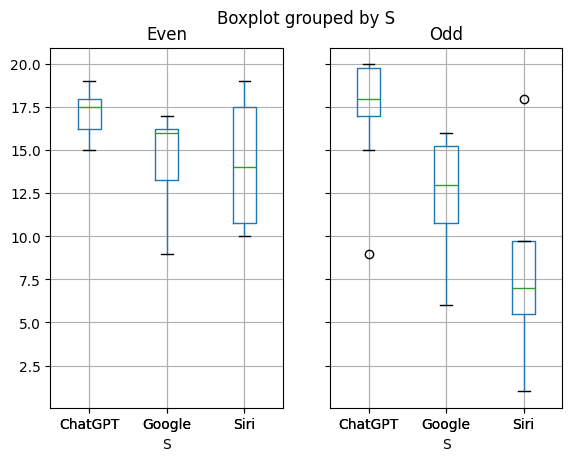

In [ ]:
# Izris boxplot po skupinah
import matplotlib.pyplot as plt

df.boxplot(by='S', column=['Even','Odd'])


In [5]:
# Izris SUS




array([[<Axes: title={'center': 'ChatGPT'}>,
        <Axes: title={'center': 'Google'}>],
       [<Axes: title={'center': 'Siri'}>, <Axes: >]], dtype=object)

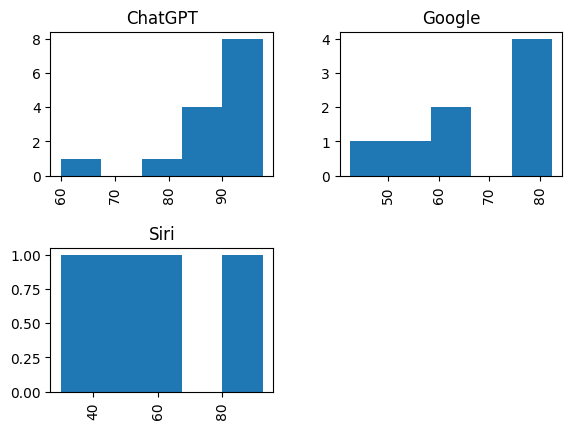

In [65]:
# Histogram SUS
df.hist(by='S', column=['SUS'], bins=5)

In [ ]:
# Preverjenaje normalnosti porazdelitev SUS v obeh skupinah

# liliefors : Ali je porazdelitev normalna, p > 0.05
from statsmodels.api import stats

S1lil = stats.diagnostic.lilliefors(df[S1]['SUS'])
print("Skupina 1: > Normalna porazd p: ", S1lil[1])
S1lil

S2lil = stats.diagnostic.lilliefors(df[S2]['SUS'])
print("Skupina 2: > Normalna porazd p: ", S2lil[1])

# Skupina 3, če je definirana


Skupina 1: > Normalna porazd p:  0.42302934384117435
Skupina 2: > Normalna porazd p:  0.15423612433507217


In [ ]:
# Razlika med skupinama: TTest

# TTest ničelna hipoteza: ni razlike med sistemi, p>0.05
from scipy import stats

NSampl = min(len(df[S1]['SUS']), len(df[S2]['SUS']))

result = stats.ttest_rel(df[S1]['SUS'][0:NSampl], df[S2]['SUS'][0:NSampl])
print('T Test result: ', result)
print('T Test p value: ', result.pvalue)

# Dodaj še primerjavo s skupino S3, če je definirana


T Test result:  TtestResult(statistic=np.float64(-3.959345503869648), pvalue=np.float64(0.0054662428829937194), df=np.int64(7))
T Test p value:  0.0054662428829937194


In [68]:
# DODATNO Cronbach alpha

if False:

    import pingouin as pg

    data1 = pd.DataFrame(df, columns=['Q1','Q3','Q5','Q7','Q9'])
    print(data1)
    print(pg.cronbach_alpha(data=data1))

    data2 = pd.DataFrame(df, columns=['Q2','Q4','Q6','Q8','Q10'])
    print(data2)
    print(pg.cronbach_alpha(data=data2))


## SUISQ Analiza

In [7]:
import pandas as pd 

# Nalozi podatke iz lokalne datoteke
fn2 = 'SUISQR_24a.xlsx'
fn2 = 'SUISQR_2026.xlsx'

suisq_column_names = ['T', 'D', 'S', 'P', 'Tema', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7',
       'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14']

df2 = pd.read_excel(fn2, names=suisq_column_names)
df2

,T,D,S,P,Tema,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14
0,2024-01-03 13:57:19.813,M,Alexa,0 Ne poznam dobro ali redko uporabljam,Nogometna tekma v Berlinu,5,6,3,4,7,7,7,6,3,3,4,5,5,5
1,2024-01-03 13:57:41.909,M,Alexa,1 Poznam govorne storitve in jih uporabljam.,Nogometne tekme,2,5,2,2,7,7,7,5,4,5,2,5,5,2
2,2024-01-03 14:07:43.640,M,Google,1 Poznam govorne storitve in jih uporabljam.,Ogled muzeja v Ljubljani,2,5,2,4,6,2,5,3,4,4,4,2,5,3
3,2024-01-03 14:10:50.987,M,Alexa,1 Poznam govorne storitve in jih uporabljam.,Ogled muzeja v Ljubljani,6,6,4,7,6,7,5,7,5,5,5,5,3,4
4,2024-01-03 14:11:52.755,M,Google,1 Poznam govorne storitve in jih uporabljam.,Nogometne tekme,3,5,2,1,5,7,7,6,3,6,6,6,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2025-12-15 14:19:58.789,M,Google,0 Ne poznam dobro ali redko uporabljam,Trenutni izidi svetovnih pokalov v zimskih špo...,2,4,2,3,5,4,4,3,4,5,4,6,5,5
66,2025-12-15 14:21:52.251,Ž,Alexa,0 Ne poznam dobro ali redko uporabljam,"potovanje v barcelone, znamenitosti, prevozi, ...",3,5,4,3,6,6,3,5,5,6,3,5,5,4
67,2025-12-15 14:24:13.782,M,Alexa,0 Ne poznam dobro ali redko uporabljam,Potovanje v Zagreb za 6 oseb,5,4,4,3,7,6,6,6,5,5,4,4,5,4
68,2025-12-18 16:21:59.288,Ž,Google,1 Poznam govorne storitve in jih uporabljam.,turistično potovanje,1,3,2,3,1,7,2,4,7,7,7,5,6,2


In [8]:
# Izracunaj faktorje UGO, CSB, SC, V:
df2['UGO']=(df2['Q1']+df2['Q2']+df2['Q3']+df2['Q4'])/4.0
#df2['CSB']=
#df2['SC']=
#df2['V']=

In [9]:
# Skupine 
S1 = df2['S']=='Alexa'
S2 = df2['S']=='Google'
S3 = df2['S']=='OpenAI'

KeyError: 'Column not found: CSB'

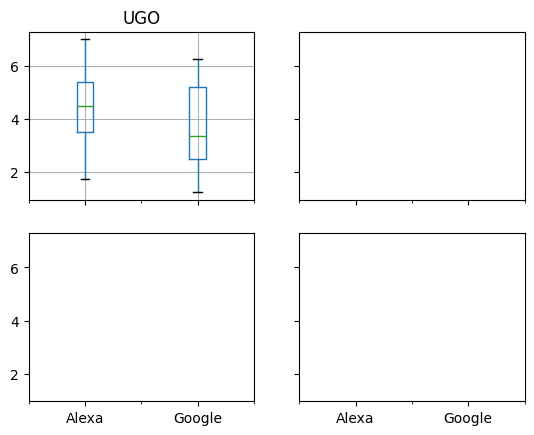

In [10]:
# Boxplot po faktorjih
df2.boxplot(by='S', column=['UGO','CSB','SC','V'])

In [89]:
# liliefors : Ali je porazdelitev normalna, p > 0.05, za vse faktorje
from statsmodels.api import stats
S1lil = stats.diagnostic.lilliefors(df2[S1]['SC'])
print("SC Normalna porazd p: ", S1lil[1])



SC Normalna porazd p:  0.9047903416714408


array([<Axes: title={'center': 'Alexa'}>,
       <Axes: title={'center': 'Google'}>], dtype=object)

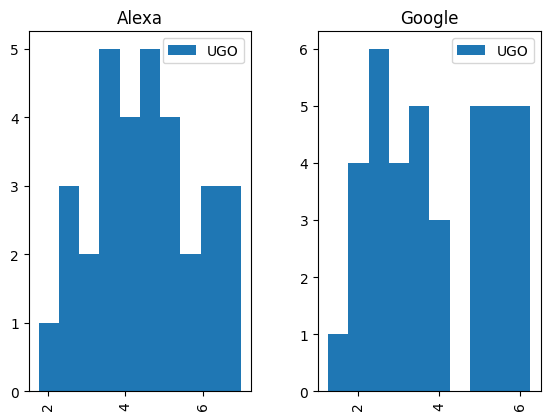

In [11]:
# Histogram verbosity
df2.hist(column=['UGO'], bins = 10, by='S',legend=True)


In [91]:
# TTest ničelna hipoteza: ni razlike med sistemi, p>0.05
from scipy import stats

NSampl = min(len(df2[S1]['UGO']), len(df2[S2]['UGO']))
print('Sample size: ', NSampl)

faktorji = ['UGO','CSB','SC','V']

for faktor in faktorji:

    result = stats.ttest_rel(df2[S1][faktor][0:NSampl], df2[S2][faktor][0:NSampl])
    print(f'T Test result for {faktor}: ', result)
    print(f'T Test p value for {faktor}: ', result.pvalue)



Sample size:  32
T Test result for UGO:  TtestResult(statistic=np.float64(1.8288471984781074), pvalue=np.float64(0.0770579564718812), df=np.int64(31))
T Test p value for UGO:  0.0770579564718812
T Test result for CSB:  TtestResult(statistic=np.float64(0.6418543684923771), pvalue=np.float64(0.5256858888529286), df=np.int64(31))
T Test p value for CSB:  0.5256858888529286
T Test result for SC:  TtestResult(statistic=np.float64(1.7840973887187497), pvalue=np.float64(0.08419990570431062), df=np.int64(31))
T Test p value for SC:  0.08419990570431062
T Test result for V:  TtestResult(statistic=np.float64(5.5215089647053323e-17), pvalue=np.float64(1.0), df=np.int64(31))
T Test p value for V:  1.0
